In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Leitura dos dados
df = pd.read_csv('casas_california.csv')

c:\Users\Meu Computador\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, '')

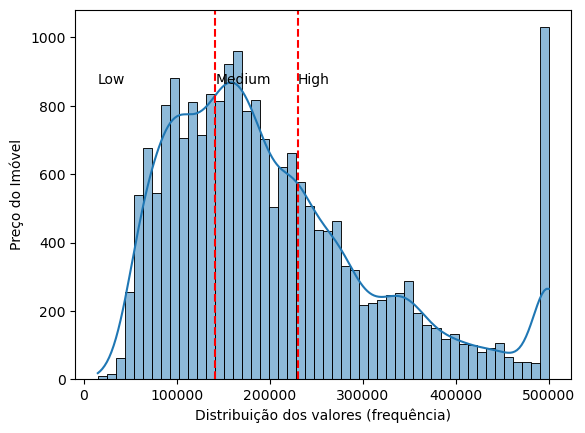

In [ ]:
# Criar categorias + bins
# Criar categorias por quartis + retornar limites
df['price_category'], bins = pd.qcut(df['valor_mediano_imoveis'], q=3, labels=['baixo', 'medio', 'alto'],retbins=True)

# Plot de um gráfico com a distribuição dos valores
sns.histplot(df['valor_mediano_imoveis'], bins=50, kde=True)

# Linhas de corte
plt.axvline(bins[1], linestyle ='--', color='red')
plt.axvline(bins[2], linestyle ='--', color='red')

# Texto (low, medium, high)
y_max = plt.gca().get_ylim()[1]
plt.text(bins[0], y_max * 0.8, 'Low')
plt.text(bins[1], y_max * 0.8, 'Medium')
plt.text(bins[2], y_max * 0.8, 'High')

plt.ylabel('Preço do Imóvel')
plt.xlabel('Distribuição dos valores (frequência)')
plt.title('Distribuição do valor mediano dos imóveis')




In [4]:
# Transformação das variáveis não numéricas
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['price_category'] = le.fit_transform(df['price_category'])
df['proximidade_oceano'] = le.fit_transform(df['proximidade_oceano'])

# Separa as entradas e saída
x = df.drop(['price_category', 'valor_mediano_imoveis'], axis=1)
y = df['price_category']

In [5]:
# Preparação dos dados de treino e teste
from sklearn.model_selection import train_test_split

xtreino, xteste, ytreino, yteste = train_test_split(x, y, test_size=0.3, random_state=42)

print(xtreino.shape)
print(ytreino.shape)
print(xteste.shape)
print(yteste.shape)

(14448, 9)
(14448,)
(6192, 9)
(6192,)


In [6]:
# Parâmetros do modelo (xgboost)
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
modelo_xgb.fit(xtreino, ytreino)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [8]:
# Avaliação do modelo
from sklearn.metrics import accuracy_score, confusion_matrix

ypred_treino = modelo_xgb.predict(xtreino)
ypred_teste = modelo_xgb.predict(xteste)

print('Acurácia de treino: ', accuracy_score(ytreino, ypred_treino))
print('Acurácia de teste: ', accuracy_score(yteste, ypred_teste))

Acurácia de treino:  0.8167220376522702
Acurácia de teste:  0.7915051679586563


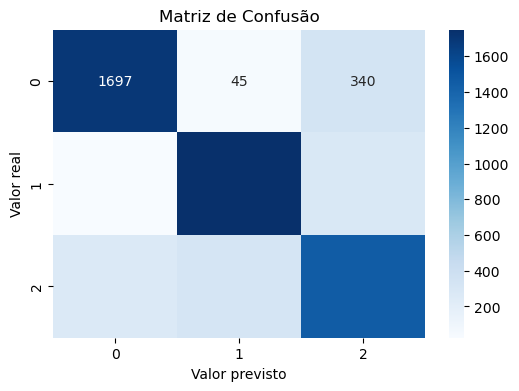

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yteste, ypred_teste)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.ylabel('Valor real')
plt.xlabel('Valor previsto')
plt.title('Matriz de Confusão')

plt.show()